## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [4]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df=pd.read_csv('shopping_trends.csv')

In [6]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [7]:
# TODO: drop the Customer ID column  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [ ]:
df=df.drop(columns=['Customer ID'])
print(df)


KeyError: "['Customer ID'] not found in axis"

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [13]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [14]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [15]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [16]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [17]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']
print(male_df)
print(female_df)

      Age Gender Item Purchased     Category  Purchase Amount (USD)  \
0      55   Male         Blouse     Clothing                     53   
1      19   Male        Sweater     Clothing                     64   
2      50   Male          Jeans     Clothing                     73   
3      21   Male        Sandals     Footwear                     90   
4      45   Male         Blouse     Clothing                     49   
...   ...    ...            ...          ...                    ...   
2647   60   Male          Shoes     Footwear                     58   
2648   51   Male          Pants     Clothing                     84   
2649   23   Male         Gloves  Accessories                     21   
2650   20   Male          Socks     Clothing                     35   
2651   51   Male       Sneakers     Footwear                     43   

            Location Size      Color  Season  Review Rating  \
0           Kentucky    L       Gray  Winter            3.1   
1              Maine 

## **EDA**

### **Item Purchased**

In [18]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top_items = male_df['Item Purchased'].value_counts().reset_index()
female_top_items = female_df['Item Purchased'].value_counts().reset_index()
all_top_items = df['Item Purchased'].value_counts().reset_index()
print("Top items for males:")
print(male_top_items)
print("Top items for females:")
print(female_top_items)
print("Top items for all customers:")
print(all_top_items)

Top items for males:
   Item Purchased  count
0           Pants    123
1         Jewelry    119
2         Sweater    114
3            Coat    114
4           Dress    114
5           Scarf    112
6           Shirt    110
7          Shorts    109
8           Skirt    109
9          Jacket    109
10       Backpack    106
11           Belt    106
12         Blouse    105
13     Sunglasses    105
14       Sneakers    103
15         Gloves    103
16          Shoes    102
17            Hat    102
18        Sandals    101
19        T-shirt    101
20          Socks    101
21         Hoodie    100
22          Jeans     95
23        Handbag     95
24          Boots     94
Top items for females:
   Item Purchased  count
0          Blouse     66
1         Sandals     59
2           Shirt     59
3         Handbag     58
4           Socks     58
5      Sunglasses     56
6            Belt     55
7          Jacket     54
8           Dress     52
9         Jewelry     52
10            Hat     52
11    

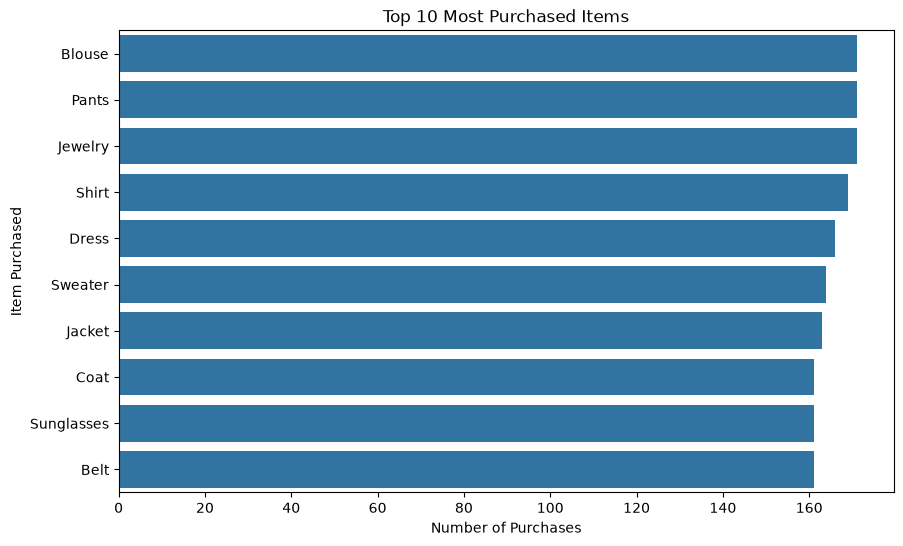

In [19]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_top_items.head(10),
    x='count',
    y='Item Purchased',
    legend=False
)

plt.title('Top 10 Most Purchased Items')
plt.xlabel('Number of Purchases')
plt.ylabel('Item Purchased')
plt.show()

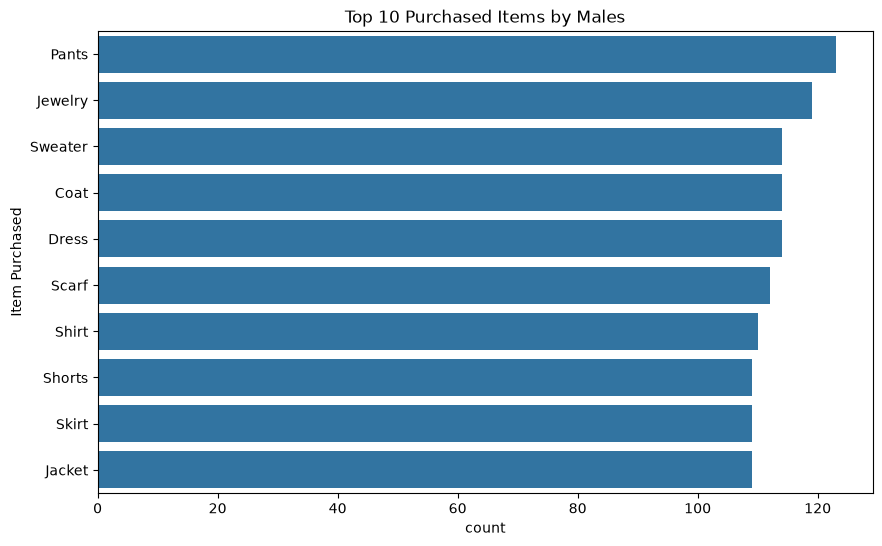

In [20]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
plt.figure(figsize=(10, 6))

sns.barplot(
    data=male_top_items.head(10),
    x='count',
    y='Item Purchased'
)

plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

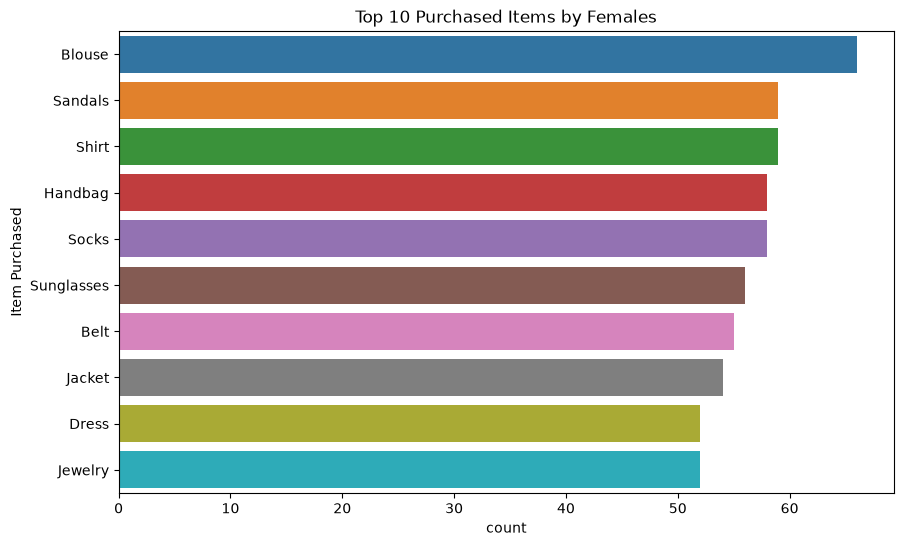

In [22]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
top_item_f = (
    df[df['Gender'] == 'Female']['Item Purchased']
    .value_counts()
    .reset_index()
)

top_item_f.columns = ['Item Purchased', 'count']
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)

plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [23]:
# TODO: count Size with value_counts() for all customers
size_counts = df['Size'].value_counts()

print(size_counts)

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64


In [24]:
# TODO: count Size with value_counts() for male_df and female_df
male_size_counts = male_df['Size'].value_counts()
female_size_counts = female_df['Size'].value_counts()

print(male_size_counts)
print(female_size_counts)

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [25]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()

print(ctg)

      Category  count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [26]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df

male_ctg = male_df['Category'].value_counts().reset_index()
female_ctg = female_df['Category'].value_counts().reset_index()

print(male_ctg)
print(female_ctg)

      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


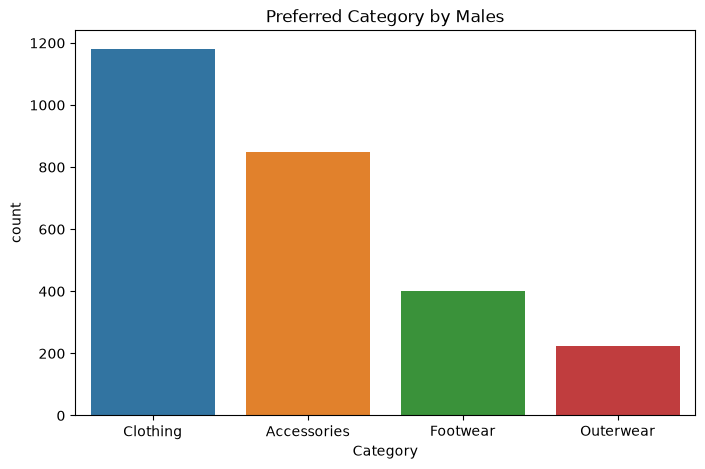

In [27]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
top_category_m = (
    df[df['Gender'] == 'Male']['Category']
    .value_counts()
    .reset_index()
)

top_category_m.columns = ['Category', 'count']
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_category_m,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)

plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

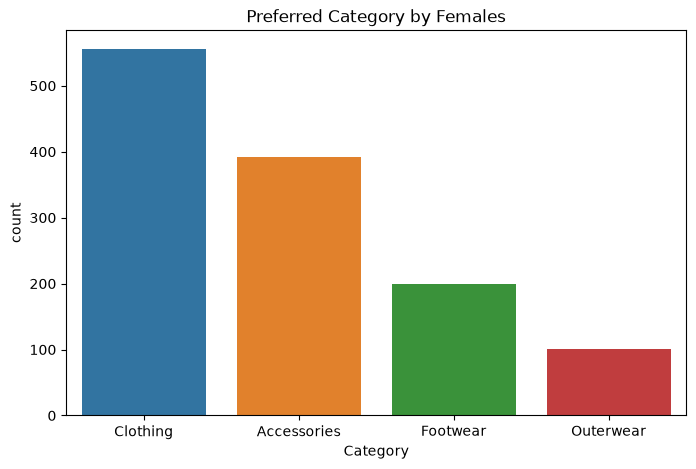

In [29]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
top_category_f = (
    df[df['Gender'] == 'Female']['Category']
    .value_counts()
    .reset_index()
)

top_category_f.columns = ['Category', 'count']
plt.figure(figsize=(8, 5))

sns.barplot(
    data=top_category_f,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)

plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

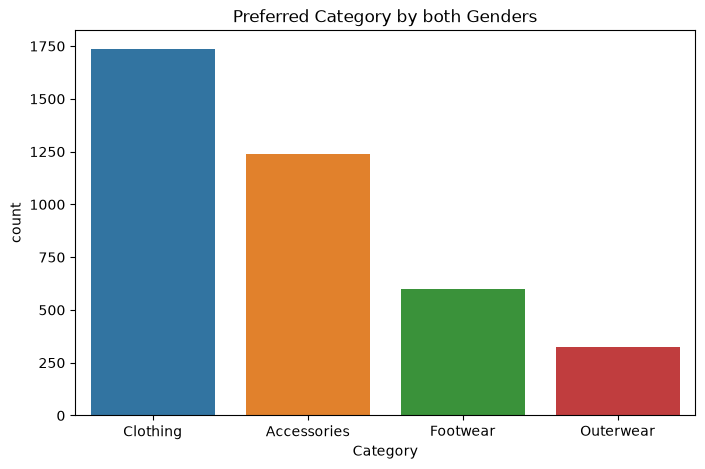

In [28]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(
data=ctg,
x='Category',
y='count',
hue='Category',
dodge=False,
legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [30]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

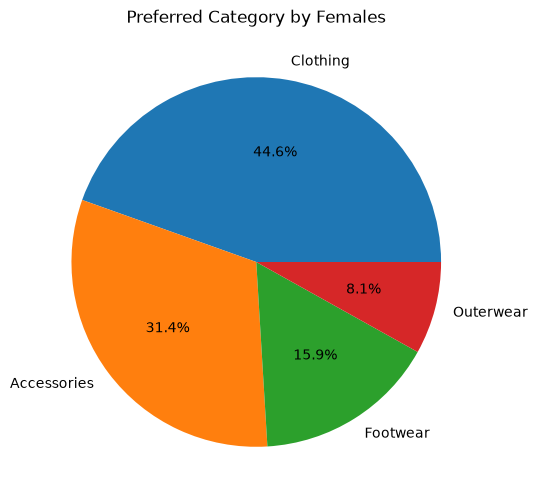

In [31]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()
plt.figure(figsize=(6, 6))

plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)

plt.title("Preferred Category by Females")
plt.show()

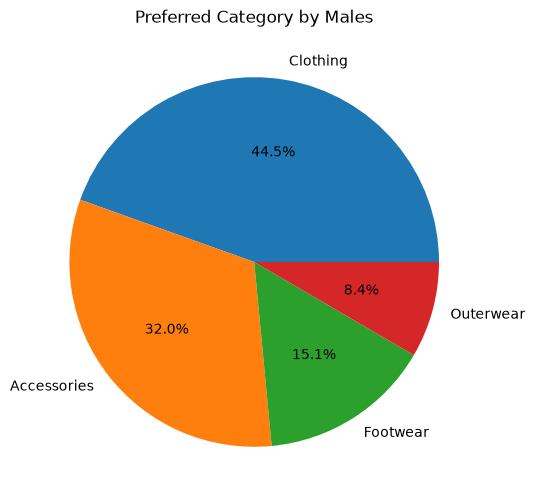

In [32]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 
plt.figure(figsize=(6, 6))

plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)

plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [35]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?
cr_f = df[(df['Gender'] == 'Female') & (df['Category'] == 'Clothing')]
avg_cr_f = cr_f['Review Rating'].mean()


In [36]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = df[(df['Gender'] == 'Male') & (df['Category'] == 'Clothing')]
avg_cr_m = cr_m['Review Rating'].mean()

In [37]:
# avg_cr_m,avg_cr_f
print(avg_cr_m)
print(avg_cr_m)

3.7319220999153258
3.7319220999153258


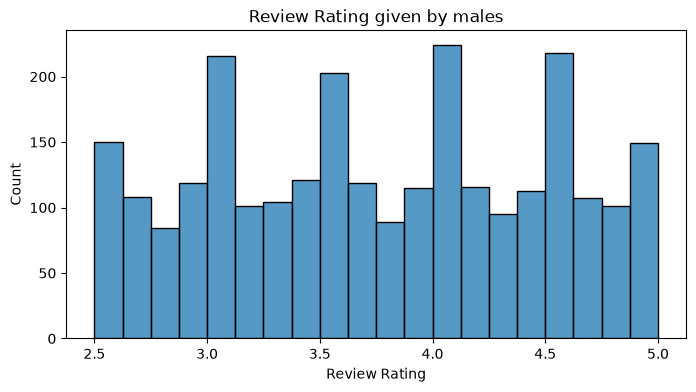

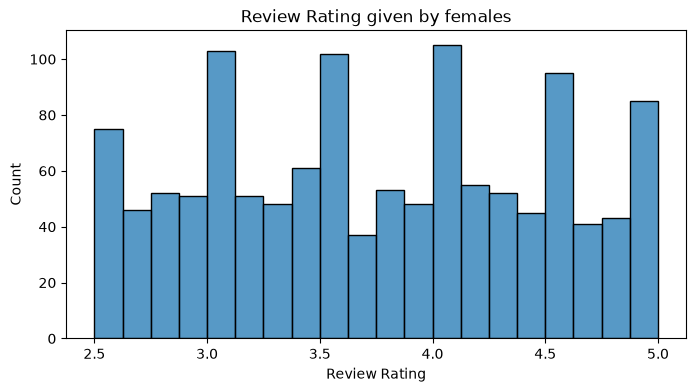

In [38]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [39]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [40]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?
m_tpa = male_df['Purchase Amount (USD)'].sum()
# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?
f_tpa = female_df['Purchase Amount (USD)'].sum()

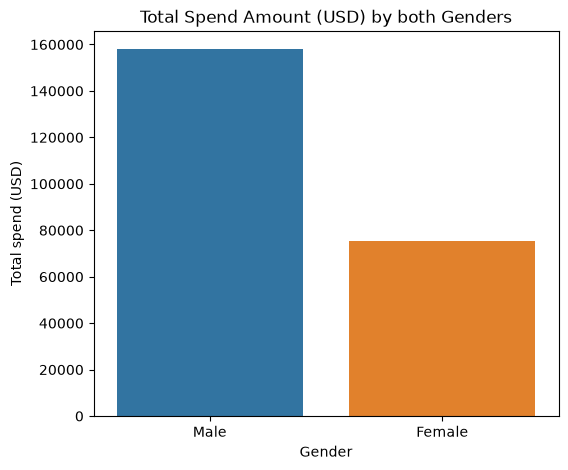

In [41]:
# TODO: plot total spend by gender with sns.barplot()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()
plt.figure(figsize=(6, 5))

sns.barplot(
    data=pd.DataFrame({
        'Gender': ['Male', 'Female'],
        'Total Spend': [m_tpa, f_tpa]
    }),
    x='Gender',
    y='Total Spend',
    hue='Gender',
    dodge=False,
    legend=False
)

plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [42]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
cf_f = female_df[female_df['Category']=='Footwear']
# co_f = ?
co_f = female_df[female_df['Category']=='Outerwear']

In [43]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category']=='Accessories']
cf_m = male_df[male_df['Category']=='Footwear']
co_m = male_df[male_df['Category']=='Outerwear']

In [44]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

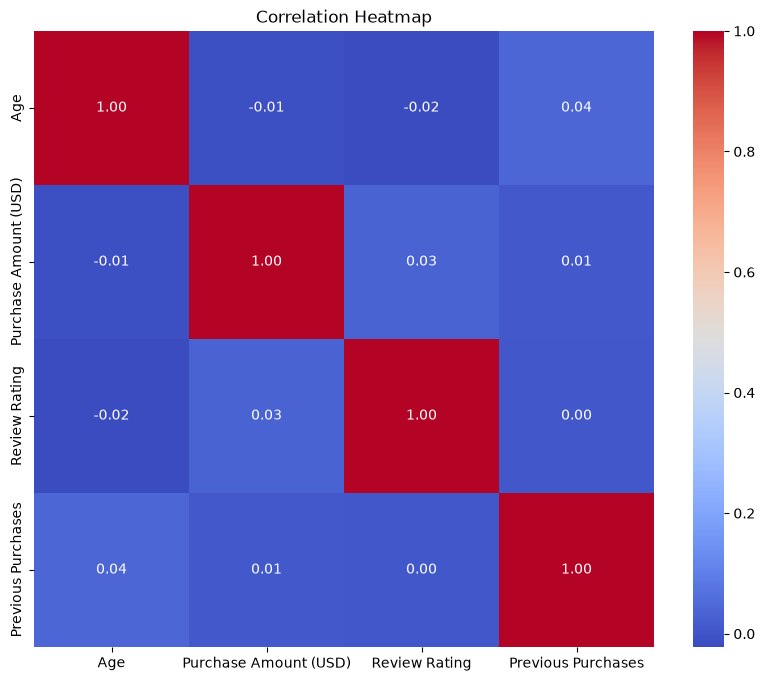

In [45]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [46]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [ ]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df['Amount_minmax'] = MinMaxScaler().fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = StandardScaler().fit_transform(df[['Age']])

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [48]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Sản phẩm và danh mục: Nam và nữ có sự khác nhau về sở thích mua sắm. Một số sản phẩm và danh mục được nam mua nhiều hơn, trong khi một số khác được nữ mua nhiều hơn.
- Tổng số tiền chi tiêu: Tổng số tiền chi tiêu của nam và nữ khá tương đồng, tuy nhiên một giới có mức chi tiêu cao hơn một chút.
- Đánh giá sản phẩm: Điểm đánh giá của nam và nữ có phân bố khá giống nhau, cho thấy mức đánh giá giữa hai giới không có sự khác biệt lớn.
- Danh mục yêu thích: Clothing là một trong những danh mục được mua phổ biến ở cả nam và nữ, trong khi các danh mục khác có số lượng mua thấp hơn.

Caveat: correlation is not causation.